In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [5]:
np.random.seed(42)
n_samples = 1000
data = pd.DataFrame({
    "fill_level": np.random.randint(10, 101, n_samples),
    "weight_kg": np.random.uniform(2, 50, n_samples),
    "temperature": np.random.uniform(20, 45, n_samples),
    "days_since_collection": np.random.randint(0, 11, n_samples),
    "odor_level": np.random.randint(1, 11, n_samples),
    "population_nearby": np.random.randint(10, 500, n_samples)
})

In [6]:
data["collection_required"] = (
    (data["fill_level"] >= 75) |
    (data["weight_kg"] >= 35) |
    (data["days_since_collection"] >= 7) |
    (data["odor_level"] >= 8)
).astype(int)
print("First 5 records:")
print(data.head())

First 5 records:
   fill_level  weight_kg  temperature  days_since_collection  odor_level  \
0          61  36.636634    24.444160                      5           4   
1          24   4.308543    37.290451                     10           6   
2          81  39.512695    35.451292                      3           9   
3          70  41.741163    35.829741                      7           2   
4          30  38.024092    25.722365                      2           7   

   population_nearby  collection_required  
0                484                    1  
1                317                    1  
2                170                    1  
3                 10                    1  
4                245                    1  


In [7]:
data.info()
print(data.shape)
print(data.describe().round(2))
print(data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   fill_level             1000 non-null   int64  
 1   weight_kg              1000 non-null   float64
 2   temperature            1000 non-null   float64
 3   days_since_collection  1000 non-null   int64  
 4   odor_level             1000 non-null   int64  
 5   population_nearby      1000 non-null   int64  
 6   collection_required    1000 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 54.8 KB
(1000, 7)
       fill_level  weight_kg  temperature  days_since_collection  odor_level  \
count     1000.00    1000.00      1000.00                1000.00     1000.00   
mean        53.44      26.27        32.45                   5.08        5.63   
std         26.53      13.55         7.30                   3.24        2.83   
min         10.00       2.01        20.00     

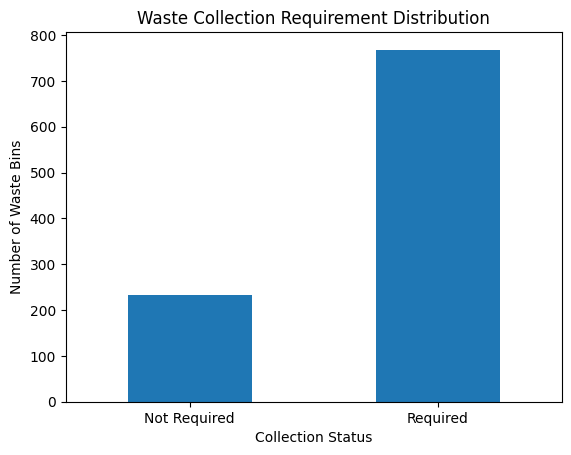

In [8]:
count_classes = data["collection_required"].value_counts().sort_index()
count_classes.plot(kind="bar", rot=0)
plt.title("Waste Collection Requirement Distribution")
plt.xticks(range(2), ["Not Required", "Required"])
plt.xlabel("Collection Status")
plt.ylabel("Number of Waste Bins")
plt.show()

In [9]:
required = data[data["collection_required"] == 1]
not_required = data[data["collection_required"] == 0]
print("Required:", required.shape)
print("Not required:", not_required.shape)

Required: (768, 7)
Not required: (232, 7)


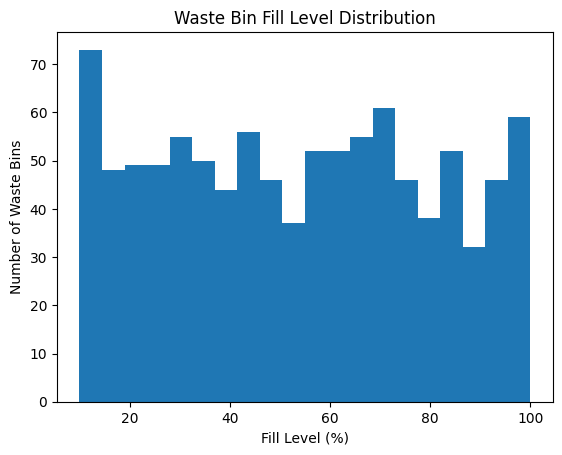

In [10]:
plt.hist(data["fill_level"], bins=20)
plt.title("Waste Bin Fill Level Distribution")
plt.xlabel("Fill Level (%)")
plt.ylabel("Number of Waste Bins")
plt.show()

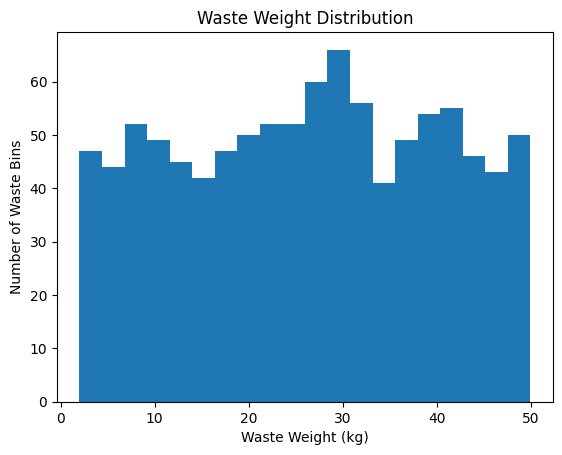

In [11]:
plt.hist(data["weight_kg"], bins=20)
plt.title("Waste Weight Distribution")
plt.xlabel("Waste Weight (kg)")
plt.ylabel("Number of Waste Bins")
plt.show()

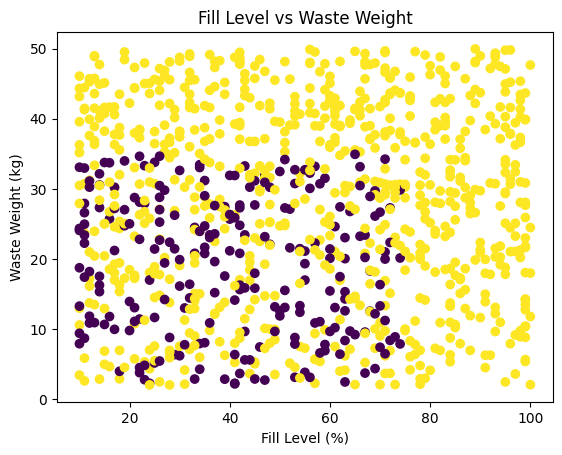

In [12]:
plt.scatter(data["fill_level"], data["weight_kg"],
            c=data["collection_required"])
plt.title("Fill Level vs Waste Weight")
plt.xlabel("Fill Level (%)")
plt.ylabel("Waste Weight (kg)")
plt.show()

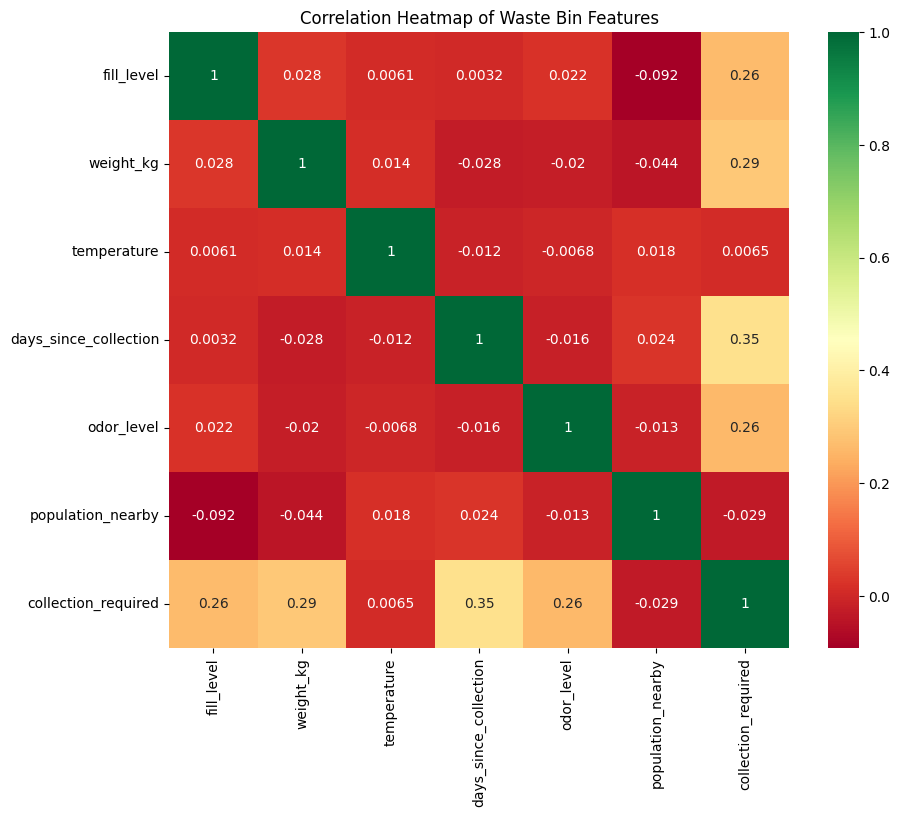

In [13]:
corrmat = data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corrmat, annot=True, cmap="RdYlGn")
plt.title("Correlation Heatmap of Waste Bin Features")
plt.show()

In [14]:
X = data.drop("collection_required", axis=1)
y = data["collection_required"]
print(X.shape)
print(y.shape)

(1000, 6)
(1000,)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(X_train.shape)
print(X_test.shape)

(800, 6)
(200, 6)


In [16]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [17]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy * 100, 2), "%")
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Model Accuracy: 100.0 %
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        46
           1       1.00      1.00      1.00       154

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Confusion Matrix:
[[ 46   0]
 [  0 154]]


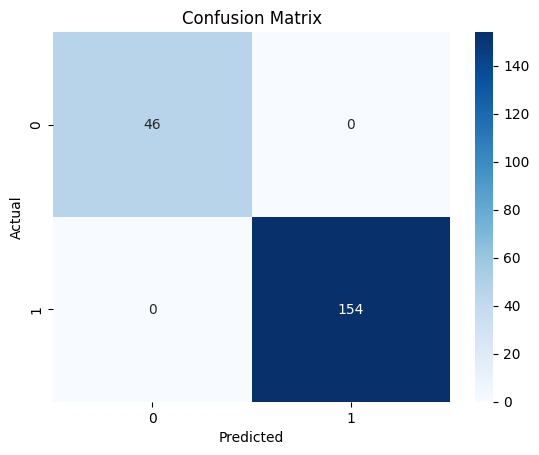

In [19]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [20]:
new_bin = pd.DataFrame({
    "fill_level": [85],
    "weight_kg": [38],
    "temperature": [32],
    "days_since_collection": [6],
    "odor_level": [7],
    "population_nearby": [250]
})
prediction = model.predict(new_bin)
if prediction[0] == 1:
    print("Prediction: COLLECTION REQUIRED")
else:
    print("Prediction: COLLECTION NOT REQUIRED")

Prediction: COLLECTION REQUIRED


In [21]:
probability = model.predict_proba(new_bin)[0][1]
print("Probability that collection is required:",
      round(probability * 100, 2), "%")

Probability that collection is required: 100.0 %


In [22]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)
print(feature_importance)

                 Feature  Importance
3  days_since_collection    0.287595
1              weight_kg    0.244014
4             odor_level    0.229406
0             fill_level    0.187048
5      population_nearby    0.027689
2            temperature    0.024247


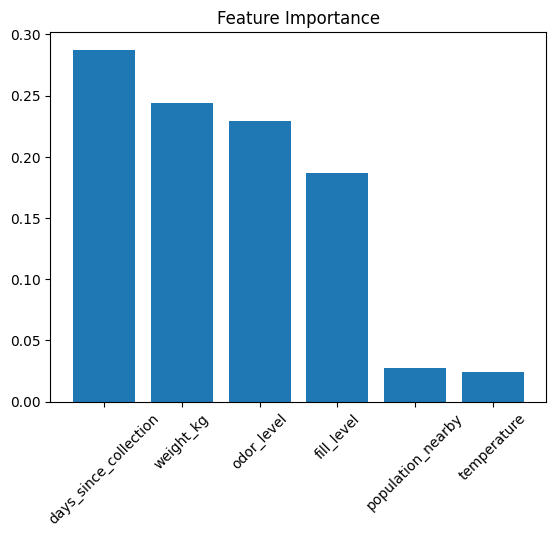

In [23]:
plt.bar(feature_importance["Feature"],
        feature_importance["Importance"])
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()